<a href="https://colab.research.google.com/github/descruceria777/Se-alesySistemas/blob/main/descrtransformadalaplacet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

– Consultar y realizar los ejercicios propuestos en el cuaderno
de Colab Convolución.

https://github.com/descruceria777/Se-alesySistemas/blob/main/2_SLIT/1_descrConvolucion.ipynb


– Consultar y realizar los ejercicios propuestos en el cuaderno
de Colab Respuesta impulso.

https://github.com/descruceria777/Se-alesySistemas/blob/main/2_SLIT/2_Respuesta_Impulso.ipynb

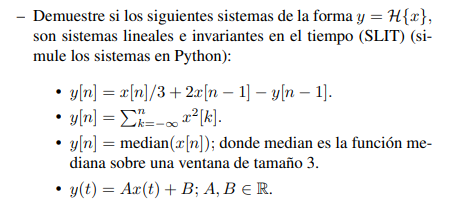

# Análisis de Sistemas: Linealidad e Invarianza en el Tiempo (SLIT)


## Sistema 1: $$(y[n] = frac{x[n]}{3} + 2x[n-1] - y[n-1]$$

### Análisis de Linealidad
Para verificar la linealidad, consideramos dos entradas arbitrarias $x_1[n]$ y    $x_2[n]$ con sus respectivas salidas $y_1[n]$ y $y_2[n]$. Aplicamos el principio de superposición:

1. Para una combinación lineal de entradas $ax_1[n] + bx_2[n]$, la salida sería:
   $$
   y[n] = \frac{ax_1[n] + bx_2[n]}{3} + 2(ax_1[n-1] + bx_2[n-1]) - y[n-1]
   $$
   
2. La combinación lineal de las salidas sería:
   $$
   ay_1[n] + by_2[n] = a\left(\frac{x_1[n]}{3} + 2x_1[n-1] - y_1[n-1]\right) + b\left(\frac{x_2[n]}{3} + 2x_2[n-1] - y_2[n-1]\right)
   $$

**Conclusión**: El sistema no es lineal porque el término recursivo \(-y[n-1]\) no permite que se cumpla el principio de superposición.

### Análisis de Invarianza en el Tiempo
Para verificar la invarianza, consideramos un desplazamiento $(k)$ en la entrada:

1. Para la entrada desplazada $[n-k]$, la salida sería:
   $$
   y_k[n] = \frac{x[n-k]}{3} + 2x[n-k-1] - y_k[n-1]
   $$
   
2. La salida desplazada \(y[n-k]\) sería:
   $$
   y[n-k] = \frac{x[n-k]}{3} + 2x[n-k-1] - y[n-k-1]
   $$

**Conclusión**: El sistema no es invariante en el tiempo porque la recursión $-y[n-1]$ introduce una dependencia temporal que afecta la invarianza.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def system1(x):
    y = np.zeros_like(x, dtype=float)
    for n in range(1, len(x)):
        y[n] = x[n]/3 + 2*x[n-1] - y[n-1]
    return y

# Prueba con diferentes entradas
n = np.arange(0, 20)
x1 = np.sin(0.1*n)
x2 = np.heaviside(n-5, 0.5)

# Linealidad: a*x1 + b*x2
a, b = 2, 3
x_combined = a*x1 + b*x2
y_combined = system1(x_combined)
y_expected = a*system1(x1) + b*system1(x2)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.stem(n, y_combined, label='Sistema(a*x1+b*x2)')
plt.stem(n, y_expected, markerfmt='rx', linefmt='r--', label='a*Sistema(x1)+b*Sistema(x2)')
plt.title('Verificación de Linealidad')
plt.legend()

# Invarianza en el tiempo
x_shifted = np.roll(x1, 5)  # Desplazamos 5 muestras
y_shifted = system1(x_shifted)
y_expected_shifted = np.roll(system1(x1), 5)

plt.subplot(2, 1, 2)
plt.stem(n, y_shifted, label='Sistema(x[n-k])')
plt.stem(n, y_expected_shifted, markerfmt='rx', linefmt='r--', label='y[n-k]')
plt.title('Verificación de Invarianza en el Tiempo')
plt.legend()
plt.tight_layout()
plt.show()


## Sistema 2: $y[n] $= $sum_{k=-\infty}^{n} x^2[k]$

### Análisis de Linealidad
Aplicamos el principio de superposición:

1. Para $ax_1[n] + bx_2[n]$, la salida sería:
   $$
   y[n] = \sum_{k=-\infty}^{n} (ax_1[k] + bx_2[k])^2 = \sum (a^2x_1^2[k] + 2abx_1[k]x_2[k] + b^2x_2^2[k])
   $$
   
2. La combinación lineal de salidas sería:
   $$
   ay_1[n] + by_2[n] = a\sum x_1^2[k] + b\sum x_2^2[k]
   $$

**Conclusión**: El sistema no es lineal debido al término cuadrático $x^2[k]$, que introduce no linealidades.

### Análisis de Invarianza en el Tiempo
Para una entrada desplazada $x[n-k]$:

1. La salida sería:
   $$
   y_k[n] = \sum_{m=-\infty}^{n} x^2[m-k] = \sum_{p=-\infty}^{n-k} x^2[p] = y[n-k]
   $$
   
**Conclusión**: El sistema es invariante en el tiempo porque el desplazamiento en la entrada produce un desplazamiento equivalente en la salida.

In [ ]:
def system2(x):
    return np.cumsum(x**2)

# Prueba de linealidad
y_combined = system2(x_combined)
y_expected = a*system2(x1) + b*system2(x2)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.stem(n, y_combined, label='Sistema(a*x1+b*x2)')
plt.stem(n, y_expected, markerfmt='rx', linefmt='r--', label='a*Sistema(x1)+b*Sistema(x2)')
plt.title('Verificación de Linealidad')
plt.legend()

# Prueba de invarianza
y_shifted = system2(x_shifted)
y_expected_shifted = np.roll(system2(x1), 5)

plt.subplot(2, 1, 2)
plt.stem(n, y_shifted, label='Sistema(x[n-k])')
plt.stem(n, y_expected_shifted, markerfmt='rx', linefmt='r--', label='y[n-k]')
plt.title('Verificación de Invarianza en el Tiempo')
plt.legend()
plt.tight_layout()
plt.show()


## Sistema 3: $y[n]= median$(x[n-1], x[n], x[n+1])$

### Análisis de Linealidad
La mediana es una operación no lineal:

1. Para $ax_1[n] + bx_2[n]$, la mediana no es igual a  $a\cdot\text{median}(x_1) + b\cdot\text{median}(x_2)$.

**Conclusión**: El sistema no es lineal porque la mediana no preserva la superposición.

### Análisis de Invarianza en el Tiempo
Para una entrada desplazada $x[n-k]$:

1. La salida sería:
   $$
   y_k[n] = \text{median}(x[n-k-1], x[n-k], x[n-k+1]) = y[n-k]
   $$
   
**Conclusión**: El sistema es invariante en el tiempo porque el cálculo de la mediana es independiente del origen temporal.



In [ ]:
from scipy.signal import medfilt

def system3(x):
    return medfilt(x, kernel_size=3)

# Prueba de linealidad
y_combined = system3(x_combined)
y_expected = a*system3(x1) + b*system3(x2)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.stem(n, y_combined, label='Sistema(a*x1+b*x2)')
plt.stem(n, y_expected, markerfmt='rx', linefmt='r--', label='a*Sistema(x1)+b*Sistema(x2)')
plt.title('Verificación de Linealidad')
plt.legend()

# Prueba de invarianza
y_shifted = system3(x_shifted)
y_expected_shifted = np.roll(system3(x1), 5)

plt.subplot(2, 1, 2)
plt.stem(n, y_shifted, label='Sistema(x[n-k])')
plt.stem(n, y_expected_shifted, markerfmt='rx', linefmt='r--', label='y[n-k]')
plt.title('Verificación de Invarianza en el Tiempo')
plt.legend()
plt.tight_layout()
plt.show()


## Sistema 4: $y(t) = Ax(t) + B$ (donde A, B ∈ R)

### Análisis de Linealidad
Aplicamos el principio de superposición:

1. Para $ax_1(t) + bx_2(t)$, la salida sería:
   $$
   y(t) = A(ax_1(t) + bx_2(t)) + B = aAx_1(t) + bAx_2(t) + B
   $$
   
2. La combinación lineal de salidas sería:
   $$
   ay_1(t) + by_2(t) = a(Ax_1(t) + B) + b(Ax_2(t) + B) = aAx_1(t) + bAx_2(t) + (a+b)B
   $$

**Conclusión**: El sistema solo es lineal si $B = 0$. En caso contrario, no es lineal debido al término constante $B$.

### Análisis de Invarianza en el Tiempo
Para una entrada desplazada $x(t-\tau)$:

1. La salida sería:
   $$
   y_\tau(t) = Ax(t-\tau) + B = y(t-\tau)
   $$
   
**Conclusión**: El sistema es invariante en el tiempo porque el desplazamiento en la entrada produce un desplazamiento equivalente en la salida.

-El sistema  sería lineal solo si $B = 0$.

In [ ]:
A, B = 2, 3

def system4(x):
    return A*x + B

t = np.linspace(0, 10, 100)
x1_cont = np.sin(t)
x2_cont = np.heaviside(t-3, 0.5)

# Prueba de linealidad
x_combined_cont = a*x1_cont + b*x2_cont
y_combined = system4(x_combined_cont)
y_expected = a*system4(x1_cont) + b*system4(x2_cont)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, y_combined, label='Sistema(a*x1+b*x2)')
plt.plot(t, y_expected, 'r--', label='a*Sistema(x1)+b*Sistema(x2)')
plt.title('Verificación de Linealidad')
plt.legend()

# Prueba de invarianza
x_shifted_cont = np.roll(x1_cont, 20)  # Desplazamiento temporal
y_shifted = system4(x_shifted_cont)
y_expected_shifted = np.roll(system4(x1_cont), 20)

plt.subplot(2, 1, 2)
plt.plot(t, y_shifted, label='Sistema(x(t-τ))')
plt.plot(t, y_expected_shifted, 'r--', label='y(t-τ)')
plt.title('Verificación de Invarianza en el Tiempo')
plt.legend()
plt.tight_layout()
plt.show()

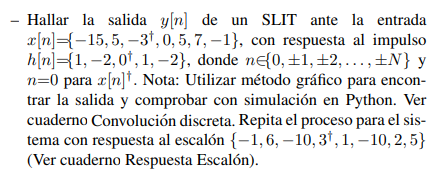

# **Cálculo de la Salida de un SLIT mediante Convolución Discreta**

## **1. Datos del Problema**
- **Entrada:**  
  $ x[n] = \{-15, 5, -3^+, 0, 5, 7, -1\} $  
  $(donde  n = 0 $ está en $x[2] = -3^+) $

- **Respuesta al impulso:**  
  $ h[n] = \{1, -2, 0^+, 1, -2\} $

 (donde  $n = 0 $ está en  $h[2] = 0^+ $)

---

## **2. Método Gráfico de Convolución Discreta**
La convolución discreta se calcula como:  
$$
y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k] \cdot h[n - k]
$$

### **Paso 1: Ajuste de Índices**
- Secuencia $x[n] $:

  Índices: $ n \in \{-2, -1, 0, 1, 2, 3, 4\} $  
  
  Valores: $ \{-15, 5, -3, 0, 5, 7, -1\} $  

- Secuencia $h[n] $:

  Índices: $n \in \{-2, -1, 0, 1, 2\} $

  Valores: $\{1, -2, 0, 1, -2\} $

### **Paso 2: Desplazamiento y Cálculo de \( y[n] \)**
Se calcula \( y[n] \) para cada desplazamiento donde haya superposición entre \( x[k] \) y \( h[n-k] \).

#### **Cálculo para cada \( n \):**
1. $ n = -4 $:
   - Solo $ k = -2 $ está en el soporte de $ x $ y $ h $.
   - $ y[-4] = x[-2] \cdot h[-2] = -15 \times 1 = -15 $.

2. **\( n = -3 \):**
   - \( k = -2 \): \( x[-2] \cdot h[-1] = -15 \times (-2) = 30 \).
   - \( k = -1 \): \( x[-1] \cdot h[-2] = 5 \times 1 = 5 \).
   - \( y[-3] = 30 + 5 = 35 \).

3. **\( n = -2 \):**
   - \( k = -2 \): \( x[-2] \cdot h[0] = -15 \times 0 = 0 \).
   - \( k = -1 \): \( x[-1] \cdot h[-1] = 5 \times (-2) = -10 \).
   - \( k = 0 \): \( x[0] \cdot h[-2] = -3 \times 1 = -3 \).
   - \( y[-2] = 0 - 10 - 3 = -13 \).

4. **\( n = -1 \):**
   - \( k = -1 \): \( x[-1] \cdot h[0] = 5 \times 0 = 0 \).
   - \( k = 0 \): \( x[0] \cdot h[-1] = -3 \times (-2) = 6 \).
   - \( k = 1 \): \( x[1] \cdot h[-2] = 0 \times 1 = 0 \).
   - \( y[-1] = 0 + 6 + 0 = 6 \).

5. **\( n = 0 \):**
   - \( k = 0 \): \( x[0] \cdot h[0] = -3 \times 0 = 0 \).
   - \( k = 1 \): \( x[1] \cdot h[-1] = 0 \times (-2) = 0 \).
   - \( k = 2 \): \( x[2] \cdot h[-2] = 5 \times 1 = 5 \).
   - \( y[0] = 0 + 0 + 5 = 5 \).

6. **\( n = 1 \):**
   - \( k = 1 \): \( x[1] \cdot h[0] = 0 \times 0 = 0 \).
   - \( k = 2 \): \( x[2] \cdot h[-1] = 5 \times (-2) = -10 \).
   - \( k = 3 \): \( x[3] \cdot h[-2] = 7 \times 1 = 7 \).
   - \( y[1] = 0 - 10 + 7 = -3 \).

7. **\( n = 2 \):**
   - \( k = 2 \): \( x[2] \cdot h[0] = 5 \times 0 = 0 \).
   - \( k = 3 \): \( x[3] \cdot h[-1] = 7 \times (-2) = -14 \).
   - \( k = 4 \): \( x[4] \cdot h[-2] = -1 \times 1 = -1 \).
   - \( y[2] = 0 - 14 - 1 = -15 \).

8. **\( n = 3 \):**
   - \( k = 3 \): \( x[3] \cdot h[0] = 7 \times 0 = 0 \).
   - \( k = 4 \): \( x[4] \cdot h[-1] = -1 \times (-2) = 2 \).
   - \( y[3] = 0 + 2 = 2 \).

9. **\( n = 4 \):**
   - Solo \( k = 4 \) está en el soporte de \( x \) y \( h \).
   - \( y[4] = x[4] \cdot h[0] = -1 \times 0 = 0 \).

---

## **3. Resultado Final de la Convolución**
La salida \( y[n] \) es:  
\[
y[n] = \{-15, 35, -13, 6, 5, -3, -15, 2, 0\}
\]  
con soporte en \( n \in \{-4, -3, \ldots, 4\} \).

---

## **4. Sistema con Respuesta al Escalón**
Dada la respuesta al escalón:  
\[
s[n] = \{-1, 6, -10, 3^+, 1, -10, 2, 5\}
\]  

### **Paso 1: Obtención de \( h[n] \)**
La respuesta al impulso se calcula como:  
\[
h[n] = s[n] - s[n-1]
\]  

#### **Ejemplo de cálculo:**
- \( h[0] = s[0] - s[-1] = 3 - (-10) = 13 \).
- \( h[1] = s[1] - s[0] = 1 - 3 = -2 \).
- Continuar para todos los índices.

### **Paso 2: Convolución con \( h[n] \)**
Una vez obtenida \( h[n] \), se repite el proceso de convolución con la entrada \( x[n] \).

